# Stochastic Differential Equation Verification Pipeline
This notebook coordinates smooth gluing computation, PRISM automated properties export, and Markov Chain Approximation validation.

In [91]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

from stochastic_verification import SDEConfig, PolynomialGluing, StochasticSimulator, generate_prism_model

%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Setup Environmental Constants and Configurations

In [92]:
config = SDEConfig(
    dt=0.05, 
    t_max=0.5, 
    tau=2.0, 
    sig=1.0, 
    h=0.002, 
    alpha=1.5, 
    beta=2.0, 
    x_max=2.5
)

# mdl = model(dt=0.05, Tmax=0.5, tau=2.0, sig=1, h=0.002, alpha=0.5, beta=0.9, xmax=2.0, seed=5)


## 2. Analytical Smooth Gluing Profile Definition

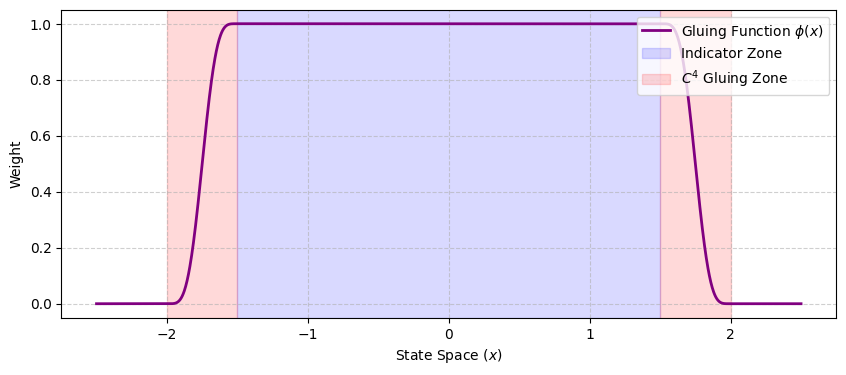

Weak Discretization Error Bound: 0.0041500841859976444
Smoothing Error Bound: 0.1501441713664403
Total Error : 0.15429425555243792


In [93]:
gluing = PolynomialGluing(config, degree=9)
fig, ax = gluing.plot_gluing_profile()
plt.show()
# error bound is wrong

(weak_error_bound,smoothing_error) = gluing.compute_error_bounds()
print(f"Weak Discretization Error Bound: {weak_error_bound}")
print(f"Smoothing Error Bound: {smoothing_error}")
total_error = weak_error_bound+smoothing_error
print(f"Total Error : {total_error}")

## 3. Statistical SDE vs Markov Chain Trajectory Simulation

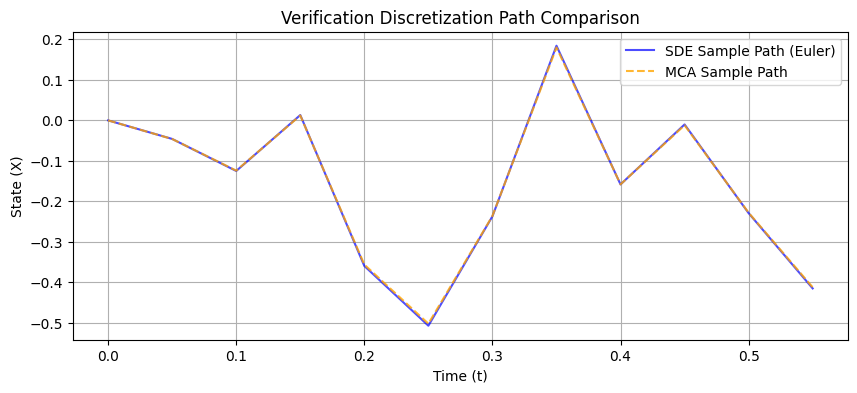

In [94]:
simulator = StochasticSimulator(config)
sim_results = simulator.run_monte_carlo(n_reps=50)

# Plot sample comparisons
plt.figure(figsize=(10, 4))
plt.plot(sim_results["time_steps"], sim_results["sde"][1], label="SDE Sample Path (Euler)", color="blue", alpha=0.7)
plt.plot(sim_results["time_steps"], sim_results["markov"][1], label="MCA Sample Path", color="orange", linestyle="--", alpha=0.8)
plt.title("Verification Discretization Path Comparison")
plt.xlabel("Time (t)")
plt.ylabel("State (X)")
plt.legend()
plt.grid(True)
plt.show()

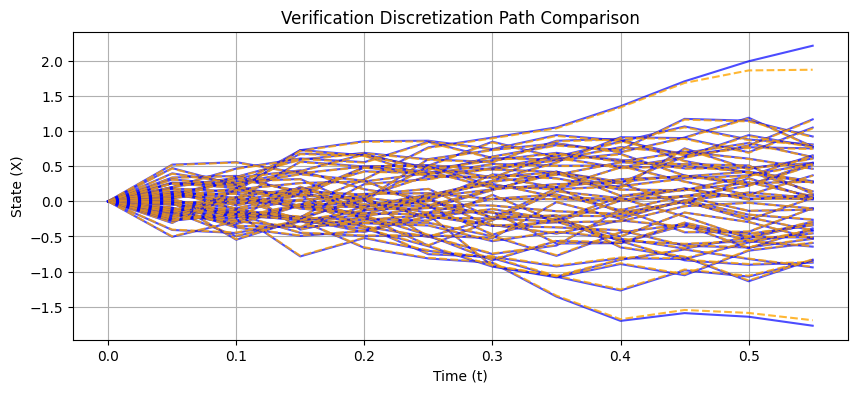

In [95]:
# print(len(sim_results["sde"]))

plt.figure(figsize=(10, 4))

for i in range(0,len(sim_results["sde"]),1):
# for i in range(50,51):
    plt.plot(sim_results["time_steps"], sim_results["sde"][i], label="SDE Sample Path (Euler)", color="blue", alpha=0.7)
    plt.plot(sim_results["time_steps"], sim_results["markov"][i], label="MCA Sample Path", color="orange", linestyle="--", alpha=0.8)
plt.title("Verification Discretization Path Comparison")
plt.xlabel("Time (t)")
plt.ylabel("State (X)")
# plt.legend()
plt.grid(True)
plt.show()

## 4. Export Configurations to PRISM Model Checker

In [96]:
# Determine state tracking parameters matching internal grid logic
x_min_val = -config.beta
initial_index = (simulator.n_states - 1) // 2

prism_code = generate_prism_model(
    tau=config.tau,
    sig=config.sig,
    h=config.h,
    n_states=simulator.n_states,
    x_min=x_min_val,
    safe_xmin=-config.alpha,
    safe_xmax=config.alpha,
    init_state=initial_index
)

with open("ou_model.sm", "w") as file:
    file.write(prism_code)

print("PRISM model structural definition file written to 'ou_model.sm'.")

PRISM model structural definition file written to 'ou_model.sm'.


## 5. Quantitative Model Verification Execution

In [97]:
# Execute verification engine command line stream
prism_path = "/home/adrien/Tools/prism/prism-4.10-linux64-x86/bin/prism"
bash_command = f"{prism_path} ou_model.sm mca_sde.pctl -exportresults res.txt"

print(f"Executing: {bash_command}")
os.system(bash_command)

Executing: /home/adrien/Tools/prism/prism-4.10-linux64-x86/bin/prism ou_model.sm mca_sde.pctl -exportresults res.txt
PRISM
=====

Version: 4.10
Date: Fri Jun 05 11:14:09 CEST 2026
Hostname: latitude
Memory limits: cudd=1g, java(heap)=7.7g
Command line: prism ou_model.sm mca_sde.pctl -exportresults res.txt

Parsing PRISM model file "ou_model.sm"...

Type:        CTMC
Modules:     MCA_Ornstein_Uhlenbeck
Actions:     []
Variables:   s
Labels:      "safe"

Parsing properties file "mca_sde.pctl"...

2 properties:
(1) P=? [ G<=T_max "safe" ]
(2) P=? [ true U[T_max,T_max] "safe" ]

---------------------------------------------------------------------

Model checking: P=? [ G<=T_max "safe" ]
Property constants: T_max=3

Building model (engine:symbolic)...

Computing reachable states...

Reachability (BFS): 1001 iterations in 0.02 seconds (average 0.000020, setup 0.00)

Time for model construction: 0.94 seconds.

Type:        CTMC
States:      2001 (1 initial)
Transitions: 4000

Rate matrix: 13

0

## 6. Verification Quantitative Analysis Output

In [100]:
if os.path.exists("res.txt"):
    with open("res.txt", "r") as file:
        prism_output = file.read()
    
    results = [float(val) for val in re.findall(r"Result\s*([0-9.eE+-]+)", prism_output)]
    
    if len(results) >= 2:
        safe_prob, terminal_safe_prob = results[:2]

        # safe_prob, terminal_safe_prob, safe_prob_max = results[:2]
        print(f"PRISM : Path Continuous Safety Probability (G <= T): {safe_prob:.6f}")
        print(f"PRISM : Fixed Horizon Transient Target Probability: {terminal_safe_prob:.6f}")
        # print(f"PRISM : Maximal Safety Control Bound Trajectory: {safe_prob_max:.6f}")

        print(f"SDE : Path Continuous Safety Probability (G <= T) interval: [{safe_prob-total_error:.6f},{safe_prob+total_error:.6f}]")
        print(f"SDE : Fixed Horizon Transient Target Probability interval: [{terminal_safe_prob-total_error:.6f},{terminal_safe_prob+total_error:.6f}]")
        
    else:
        print("PRISM file parsing completed but unexpected metrics length encountered.")
else:
    print("Results file 'res.txt' not found. Ensure PRISM path location configurations match operational environment specifications.")

PRISM : Path Continuous Safety Probability (G <= T): 0.426694
PRISM : Fixed Horizon Transient Target Probability: 0.914956
SDE : Path Continuous Safety Probability (G <= T) interval: [0.272400,0.580988]
SDE : Fixed Horizon Transient Target Probability interval: [0.760661,1.069250]
